# Flash Attention - V2


In [1]:
from helper import plot, count_fa2
from math import ceil

## Quantization & Int8 -> Int16 stability

W8A16 outlier

Original LlaMA 8B is a BF16 model, while running on this architecture have to be W8A16. A quantization should be explicitly
designed for rounding.

Ref:  SageAttention2: Efficient Attention with Thorough Outlier Smoothing and Per-thread INT4 Quantization

For activation, Int 16 and Int8 are used and **radix-16 digit decomposition** has been applied for numerical accumulator stability

$A = A_0 + 16A_1, B = B_0 + 16B_1$

$AB = A_0 B_0 + 16A_0 B_1 + 16 A_1 B_0 + 256 A_1 B_1$

ref: BISMO: A Scalable Bit-Serial Matrix Multiplication Overlay for Reconfigurable Computing



## Prefill

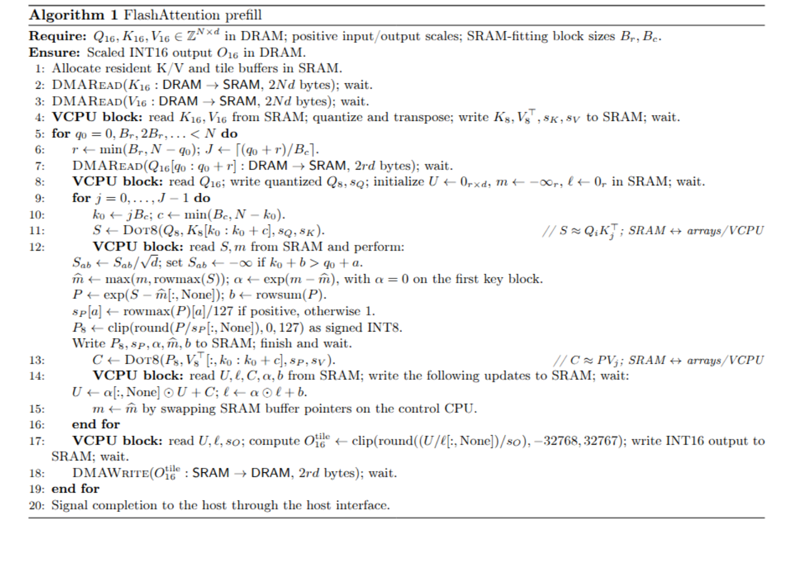

In [2]:
plot("img/fa2_prefill.png", 800)

    DMA load K16, V16
    VCPU V16 -> K8
    VCPU pack transposed V8
    SRAM write K8, packed V8, sK, sV

    FOR i
        DMA load Qi16
        VCPU Qi16 -> Qi8, sQ
        VCPU initialize FP32 U = 0, l = 0, m = -infinity
        SRAM write Qi8, sQ, U, l, m

        FOR j
            VCPU Qi8, Kj8
            SRAM write Q digits, K digits

            CPU issue overlapping SA1 & SA2 commands for physical tiles
            SA1 & SA2 preload Q digits, K digits from SRAM
            SA1 & SA2 compute S16 digit-pair partials
            SRAM write S16 partials
            CPU wait for required SA results

            VCPU reconstruct S16 partials using INT32
            VCPU apply sQ, sK -> S_FP32
            SRAM write S_FP32

            VCPU read S_FP32, m
            VCPU scale S_FP32 by 1/sqrt(d) and apply causal mask
            VCPU compute new_m = max(m, rowmax(S_FP32))
            VCPU compute alpha = exp(m - new_m)
            VCPU compute P_FP32 = exp(S_FP32 - new_m)
            VCPU compute b = rowsum(P_FP32)
            VCPU quantize P_FP32 -> P8, row scales sP
            SRAM write P8, sP, alpha, b, new_m

            VCPU pack P8, Vj8 -> signed digit planes
            SRAM write P digits, V digits

            CPU issue overlapping SA1 & SA2 commands for physical tiles
            SA1 & SA2 preload P digits, V digits from SRAM
            SA1 & SA2 compute C16 digit-pair partials
            SRAM write C16 partials
            CPU wait for required SA results

            VCPU reconstruct C16 partials using INT32
            VCPU apply sP, sV -> C_FP32
            SRAM write C_FP32

            VCPU read U, l, C_FP32, alpha, b
            VCPU update U = alpha * U + C_FP32
            VCPU update l = alpha * l + b
            SRAM write U, l
            CPU swap m and new_m buffer pointers
        END FOR

        VCPU read U, l
        VCPU normalize Oi = U / l
        VCPU quantize Oi -> Oi16 using output scale sO
        SRAM write Oi16
        DMA store Oi16: SRAM -> DRAM; wait
    END FOR

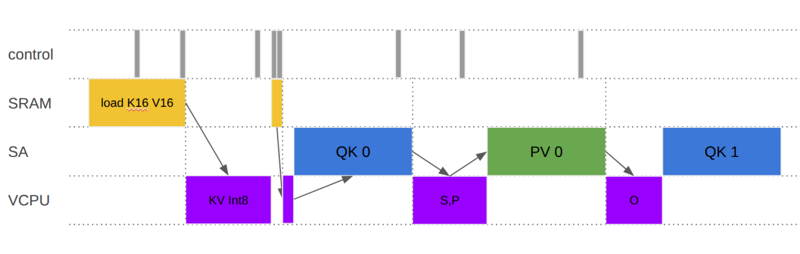

In [3]:
plot("img/fa2_schedule.png", 800)

## Improve:

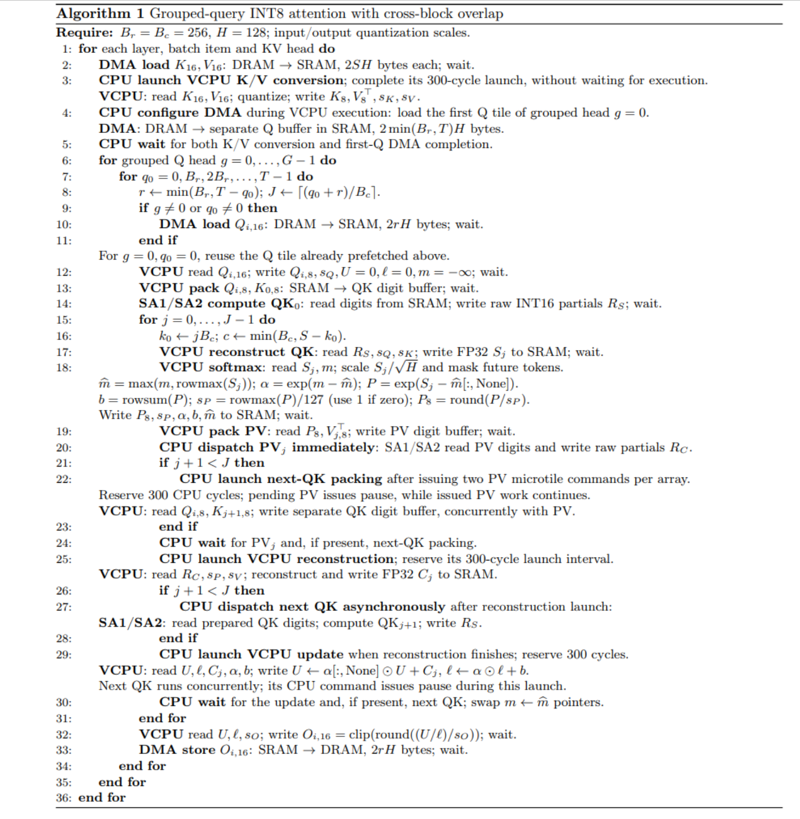

In [4]:
plot("img/fa2_v2_prefill.png", 800)

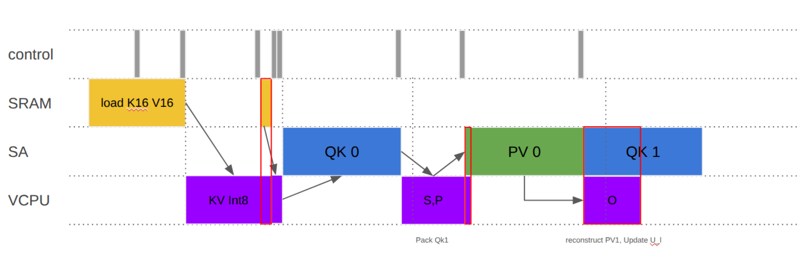

In [5]:
plot("img/fa2_v2_schedule.png", 800)

## Find the best Br Bc to minimize the overhead

two operations uses SA unit

    1 S = Q K^T
    2 P V

$$\min T(B_r, Bc)_{B_r, B_c} s.t. M_{SRAM}(B_r, B_c) <= 16MB$$

from math import ceilBandwidth model

**The 8 B/c output port is the bottleneck.**

**sa2 has no advantage on K = 128, and a 2﷿﷿ advantage on k = 256.**

**K >= 128 Memory bound, <= computation bound**

when K = 128, sa1 complete same macs in the same cycle (128)

    K=32
    sa1 macs: 8192, cycle:64
    sa2 macs: 16384, cycle:128
    K=64
    sa1 macs: 16384, cycle:64
    sa2 macs: 32768, cycle:128
    K=128
    sa1 macs: 32768, cycle:64
    sa2 macs: 65536, cycle:128
    K=256
    sa1 macs: 65536, cycle:128
    sa2 macs: 131072, cycle:128


suggest: QK: K = 128, both row_size = 32n

-> Br1 = Br2 = Br / 2

-> Br can be divisible by 32 and ideally // 2048

-> Br in {64, 128, 192, 256 512...}

suggest PV: reduction in Bc, should be overflow safe avoids a short final reduction chunk in PV

-> Bc in {128, 256, 512 ...}


Mac mode

    K=32
    sa1 macs: 8192, cycle:64
    sa2 macs: 16384, cycle:128
    K=64
    sa1 macs: 16384, cycle:64
    sa2 macs: 32768, cycle:128
    K=128
    sa1 macs: 32768, cycle:128
    sa2 macs: 65536, cycle:128
    K=256
    sa1 macs: 65536, cycle:256
    sa2 macs: 131072, cycle:256

suggest: QK: K = 128, 1:1


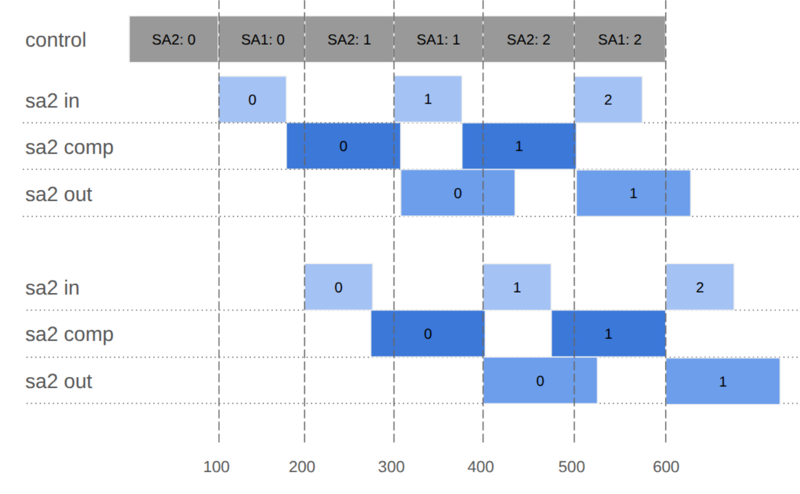

In [6]:
plot("img/schedule.png", 800)

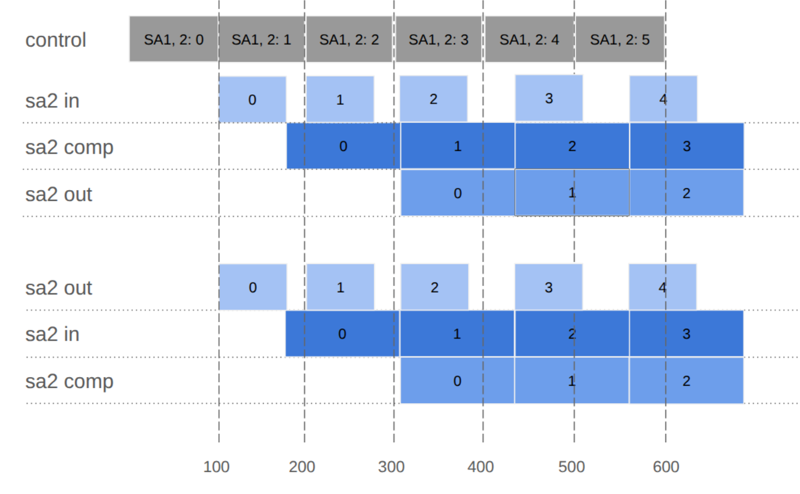

In [7]:
plot("img/schedule_seq.png", 800)

## Performance analysis

In [8]:
B = 16 # Batch size
L = 32 # Layers
T = 2048 # Q length
S = 2048 # K length
D = 4096 # dimension
F = 14336 # FFN inter dim
N = 32 # Q head
K = 8 # KV head
H = 128 # d_head
G = int(N / K) # Q heads / KV head
d_kv = 1024 # d_kv


In [9]:
from math import ceil
from tile_model import Hardware, DMA, VCPU, SA1, SA2


def analytical(Br_SA1, Br_SA2, Bc, R,
               hw=Hardware(control="pipelined")):

    Br = Br_SA1 + Br_SA2
    G = N // K
    Q_offset = 0

    Digit_pairs = hw.digits**2

    # Your formulas assume pipelined command issue.
    # This helper receives TOTAL vector read + write traffic.
    def vector_cycles(total_bytes):
        return VCPU(
            in_bytes=total_bytes,
            out_bytes=0,
            hw=hw,
        ).launch_cycle()

    # Physical array dimensions and bandwidths come from the classes.
    sa1 = SA1(K=R, compute_model="mac")
    sa2 = SA2(K=R, compute_model="mac")

    # K/V loaded once for all G grouped Q heads.
    DMA_K = DMA(
        nbytes=2 * S * H, direction="read", hw=hw
    ).cycle()

    DMA_V = DMA(
        nbytes=2 * S * H, direction="read", hw=hw
    ).cycle()

    VCPU_KV = vector_cycles(10 * S * H + 16)
    KV_setup = DMA_K + DMA_V + VCPU_KV

    Q_head_BW = 0
    Q_head_MAC = 0

    for q0 in range(0, T, Br):
        r = min(Br, T - q0)
        r1 = min(r, Br_SA1)
        r2 = r - r1

        Row_tiles1 = ceil(r1 / sa1.physical_rows)
        Row_tiles2 = ceil(r2 / sa2.physical_rows)

        Padded_rows = (
            Row_tiles1 * sa1.physical_rows
            + Row_tiles2 * sa2.physical_rows
        )

        DMA_Q = DMA(
            nbytes=2 * r * H, direction="read", hw=hw
        ).cycle()

        DMA_O = DMA(
            nbytes=2 * r * H, direction="write", hw=hw
        ).cycle()

        VCPU_Q = vector_cycles(9 * r * H + 8 * r + 8)
        VCPU_O = vector_cycles(6 * r * H + 4 * r + 4)

        Q_head_BW += DMA_Q + DMA_O + VCPU_Q + VCPU_O
        Q_head_MAC += DMA_Q + DMA_O + VCPU_Q + VCPU_O

        for k0 in range(0, min(S, Q_offset + q0 + r), Bc):
            c = min(Bc, S - k0)

            Softmax = vector_cycles(17 * r * c + 28 * r)
            Update = vector_cycles(12 * r * H + 16 * r)

            Q_head_BW += Softmax + Update
            Q_head_MAC += Softmax + Update

            for product, columns, reduction in [
                ("QK", c, H),
                ("PV", H, c),
            ]:
                Chunks = ceil(reduction / R)

                # Preserve your fixed-depth padding.
                Padded_reduction = Chunks * R

                # Both arrays have 16 physical output columns.
                Physical_columns = sa1.output_bytes() // (
                    sa1.physical_rows * 2
                )
                Column_tiles = ceil(columns / Physical_columns)
                Padded_columns = Column_tiles * Physical_columns

                Jobs1 = Row_tiles1 * Column_tiles * Chunks * Digit_pairs
                Jobs2 = Row_tiles2 * Column_tiles * Chunks * Digit_pairs

                Raw_bytes = (
                    Jobs1 * sa1.output_bytes()
                    + Jobs2 * sa2.output_bytes()
                )

                Pack = vector_cycles(
                    (r + columns) * reduction
                    + hw.digits
                    * (Padded_rows + Padded_columns)
                    * Padded_reduction
                )

                Scale_bytes = 8 if product == "QK" else 4 * r + 4

                Recon = vector_cycles(
                    Raw_bytes
                    + 4 * r * columns
                    + Scale_bytes
                )

                # Preserve your first-command ordering.
                Start1 = 0 if Jobs1 > Jobs2 else hw.issue_interval
                Start2 = hw.issue_interval if Jobs1 > Jobs2 else 0

                End_BW = []
                End_MAC = []

                for sa, jobs, start in [
                    (sa1, Jobs1, Start1),
                    (sa2, Jobs2, Start2),
                ]:
                    if jobs == 0:
                        End_BW.append(0)
                        End_MAC.append(0)
                        continue

                    Input = sa.input_cycles()
                    Output = sa.output_cycles()
                    Compute = sa.compute_cycles()  # R in MAC model.

                    End_BW.append(
                        start
                        + hw.array_latency
                        + Input
                        + Output
                        + (jobs - 1) * max(Input, Output)
                    )

                    End_MAC.append(
                        start
                        + hw.array_latency
                        + Input
                        + Compute
                        + Output
                        + (jobs - 1) * max(Input, Compute, Output)
                    )

                Q_head_BW += Pack + Recon + max(End_BW)
                Q_head_MAC += Pack + Recon + max(End_MAC)

    First_Q_DMA = DMA(
        nbytes=2 * min(Br, T) * H,
        direction="read",
        hw=hw,
    ).cycle()

    Hidden_Q_DMA = min(
        First_Q_DMA,
        VCPU_KV - hw.vector_launch,
    )

    FA2_BW_cycles = KV_setup + G * Q_head_BW - Hidden_Q_DMA
    FA2_MAC_cycles = KV_setup + G * Q_head_MAC - Hidden_Q_DMA

    FA2_BW_ms = round(hw.time_us(FA2_BW_cycles) / 1000, 3)
    FA2_MAC_ms = round(hw.time_us(FA2_MAC_cycles) / 1000, 3)

    return FA2_BW_ms, FA2_MAC_ms

In [10]:
for R in [64, 128, 256]:
    for Br_SA1 in [16, 32, 64, 128, 256]: # Must be a multiple of 16
        for Br_SA2 in [32, 64, 128, 256]:
            for Bc in  [128, 256, 512]:
                FA2_BW_ms, FA2_MAC_ms = analytical(Br_SA1, Br_SA2, Bc, R)
                print(R, Br_SA1, Br_SA2, Bc, FA2_BW_ms, FA2_MAC_ms)
    print("*"*72)

64 16 32 128 34.49 34.681
64 16 32 256 34.056 34.157
64 16 32 512 36.339 36.395
64 16 64 128 37.465 37.583
64 16 64 256 37.734 37.795
64 16 64 512 40.916 40.95
64 16 128 128 41.34 41.413
64 16 128 256 42.19 42.228
64 16 128 512 45.133 45.154
64 16 256 128 44.25 44.291
64 16 256 256 47.391 47.413
64 16 256 512 50.374 50.385
64 32 32 128 26.559 26.699
64 32 32 256 26.193 26.267
64 32 32 512 28.0 28.041
64 32 64 128 32.744 32.845
64 32 64 256 33.036 33.089
64 32 64 512 35.43 35.46
64 32 128 128 37.056 37.117
64 32 128 256 37.725 37.757
64 32 128 512 40.769 40.787
64 32 256 128 42.735 42.777
64 32 256 256 44.069 44.091
64 32 256 512 47.088 47.099
64 64 32 128 32.744 32.845
64 64 32 256 33.036 33.089
64 64 32 512 35.43 35.46
64 64 64 128 24.93 24.999
64 64 64 256 25.068 25.105
64 64 64 512 27.091 27.111
64 64 128 128 31.348 31.4
64 64 128 256 31.818 31.845
64 64 128 512 34.364 34.379
64 64 256 128 37.293 37.329
64 64 256 256 38.717 38.736
64 64 256 512 41.809 41.819
64 128 32 128 38.105 38.

**128 128 128 256 13.897725 23.353053**

**128 64 128 256 17.749221 18.847909**

for bandwidth 1:1, mac 1:2

### Using Hardware model

In [11]:
from fa import flash_attention

result = flash_attention(T=T, S=S, H=H, G=G, Br=32, Bc=128,
                    Br_sa1=None, R=256)

Load K16                                        8,592 cycles        8.592 us  SRAM    512.00 KiB
Load V16                                        8,592 cycles        8.592 us  SRAM   1024.00 KiB
Quantize K/V + transpose V                     20,781 cycles       20.781 us  SRAM   1536.01 KiB
h0 q0 load Q16                                    528 cycles        0.528 us  SRAM    520.01 KiB
h0 q0 quantize Q + init U,l,m                     591 cycles        0.591 us  SRAM    540.26 KiB
h0 q0 k0 QK pack                                1,068 cycles        1.068 us  SRAM    608.26 KiB
h0 q0 k0 QK arrays                              7,524 cycles        7.524 us  SRAM    656.26 KiB
  SA1: 32 commands, 7,360 cycles (7.360 us); starts +0 cycles in GEMM
  SA2: 32 commands, 7,424 cycles (7.424 us); starts +100 cycles in GEMM
h0 q0 k0 QK reconstruct                           813 cycles        0.813 us  SRAM    596.26 KiB
h0 q0 k0 softmax + P8                             593 cycles        0.593 us  SRAM

### Conclusion

FA2_overlap

SA distribution

Best practice Br

Quantization: Accumulator overflow and quantization control on FA

Problems:

    1 Output bottleneck: The sa computation is largely limited by its output bound (See hardware profile). SA2 optimal K = 256, but restricted by quantization K<= 128, otherwise overflow could happen.

    2 Different Br doesn't improve. the Br1 and Br2 doesn't get any improve compare with identical Br for both sa


3 pipeline instruction

